In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf 
import statsmodels.api as sm 

In [35]:
tickers = ["SVIX", "^PUT"]
PUT_prices = yf.download("^PUT", start = "2011-01-01", end = "2026-01-01")
SVIX_prices = yf.download("SVIX", start = "2011-01-01", end = "2026-01-01")

prices_put = PUT_prices["Close"]
prices_svix = SVIX_prices["Close"]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

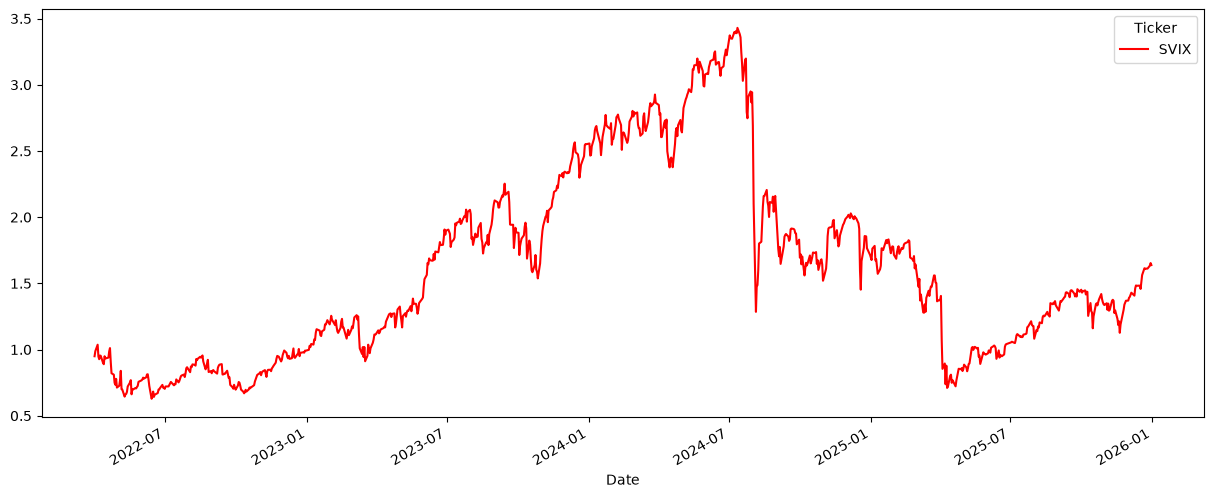

In [63]:
# SVIX is long VIX futures, 

rets_svix = prices_svix.pct_change() + 1
compound_rets_svix = rets_svix.cumprod()
compound_rets_svix.plot(figsize=(15,6), color='Red')

<Axes: title={'center': 'Selling Puts Returns'}, xlabel='Date'>

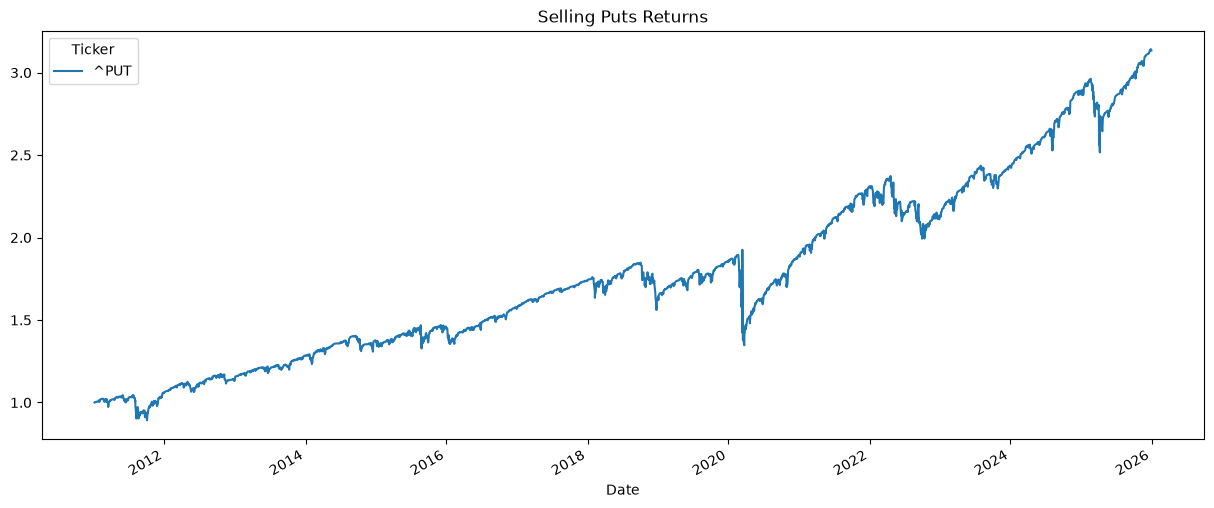

In [55]:
rets_put = prices_put.pct_change() + 1
compound_rets_put = rets_put.cumprod()
compound_rets_put.plot(title='Selling Puts Returns', figsize=(15,6))

In [53]:
#sharpe ratio and metrics for selling puts
rets = prices_put.pct_change() 
annulised_rets = rets.mean() *252
annulised_vol = rets.std() * np.sqrt(252)
sharpe = annulised_rets / annulised_vol
print(sharpe)


Ticker
^PUT    0.542424
dtype: float64


<Axes: title={'center': 'Drawdowns'}, xlabel='Date'>

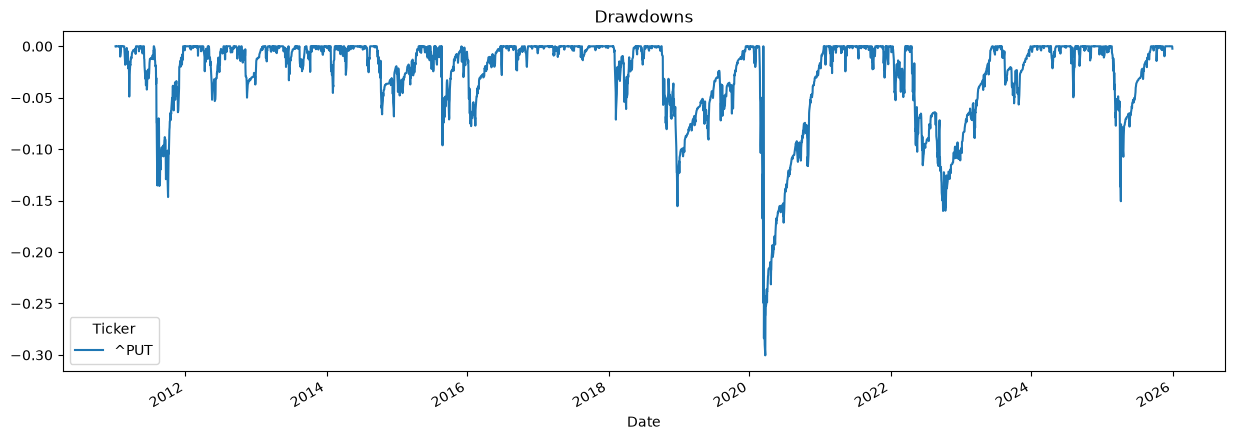

In [57]:
# drawdowns 
total_rets = (rets + 1).cumprod()
previous_peaks = total_rets.cummax()
drawdowns = (total_rets - previous_peaks) / previous_peaks
drawdowns.plot(title="Drawdowns", figsize = (15,5))